In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Dict

from model_ranking import (
    load_h5,
    find_selftraining_pred_paths,
    identify_transfer,
    get_output_paths,
)
from model_ranking import (
    get_ckpt_eval_scores
)
from pytorch3dunet.unet3d.config import load_config_direct

/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


INFO: P [MainThread] 2026-07-06 14:57:13,492 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
approach_mapping = {
    "DO": "feature_perturbation",
    "def": "default_selftraining",
    "cfd": "confidence_threshold",
    "F1": "direct_eval",
    "torchem": "supervised_torchem",
    "_SF_": "supervised",
    "ST": "supervised_training",
}

In [3]:
models: Dict[str, List[str]] = {
    "HtoE": [
        "HtoE_DOa02_th08_new_model1",
        "HtoE_def_new_model1",
        "HtoE_cfd09_new_model1",
        "HtoE_F108_new_model2", 
        # "HtoE_SSdef_new_model1", 
        # "HtoE_SFtorchem_model5",
    ],
    # "VtoE": [
    #     "VtoE_DOa02_th07_new_model1",
    #     "VtoE_def_new_model1",
    #     "VtoE_cfd09_new_model1",
    #     "VtoE_F106_model1",
    #     "VtoE_SFtorchem_new_model1",
    # ],
    "HtoR": [
        "HtoR_cfd09_new_model1",
        "HtoR_def_new_model1",
        "HtoR_DOa02_th08_new_model1",
        "HtoR_F108_new_model1",
        # "HtoR_SFtorchem_new_model1",
    ],
    # "RtoH": [
    #     "RtoH_cfd09_new_model1",
    #     "RtoH_def_new_model1",
    #     "RtoH_DOa02_th08_new_model1",
    #     "RtoH_F107_new_model1",
    #     "RtoH_SFtorchem_new_model1",
    # ],
    "EtoH": [
        "EtoH_cfd09_new_model1",
        "EtoH_def_new_model1",
        "EtoH_DOa02_th08_new_model1",
        "EtoH_F1075_new_model1",
        #"EtoH_SFtorchem_new_model1",
    ],
    # "EtoR": [
    #     "EtoR_cfd09_new_model1",
    #     "EtoR_def_new_model1",
    #     "EtoR_DOa02_th08_new_model1",
    #     "EtoR_F1075_new_model1",
    #     "EtoR_SFtorchem_new_model1",
    # ],
    # "EtoV": [
    #     "EtoV_cfd09_new_model1",
    #     "EtoV_def_new_model1",
    #     "EtoV_def_new_model2",
    #     "EtoV_DOa02_th08_new_model1",
    #     "EtoV_F107_new_model1",
    #     "EtoV_SFtorchem_new_model1",
    # ],
    # "HtoV": [
    #     "HtoV_def_new_model1",
    # ],
    # "RtoE": [
    #     "RtoE_def_new_model1",
    # ],
    # "RtoV": [
    #     "RtoV_def_new_model1",
    # ],
    # "VtoH": [
    #     "VtoH_def_new_model1",
    # ],
    # "VtoR": [
    #     "VtoR_def_new_model1",
    # ],

}

Transfer: HtoE


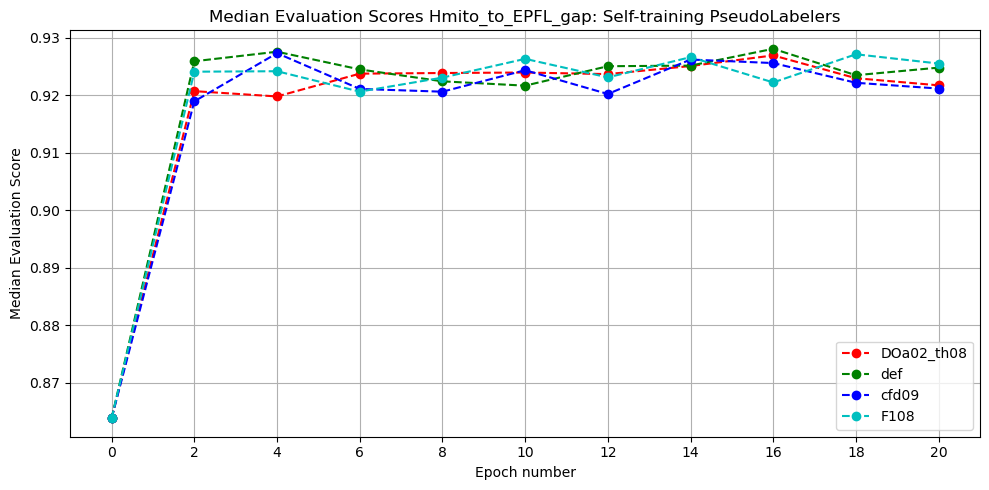

Transfer: HtoR


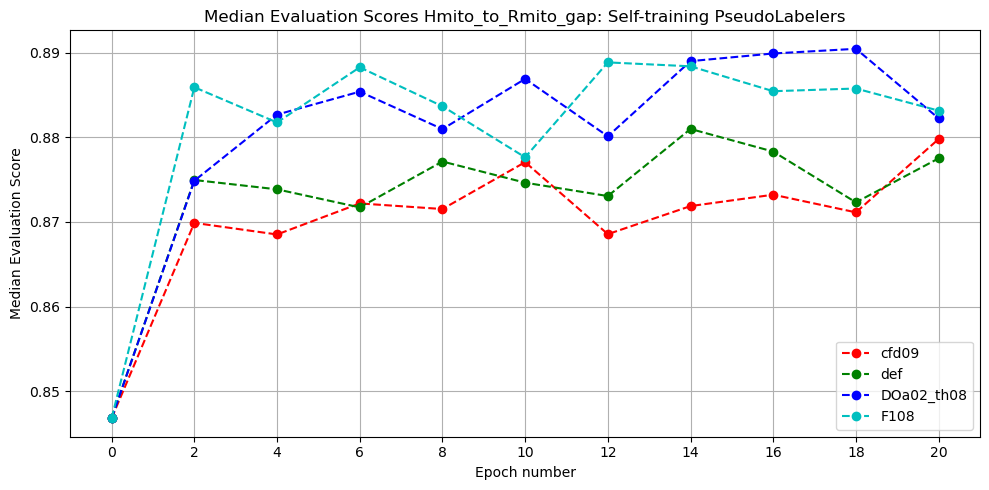

Transfer: EtoH


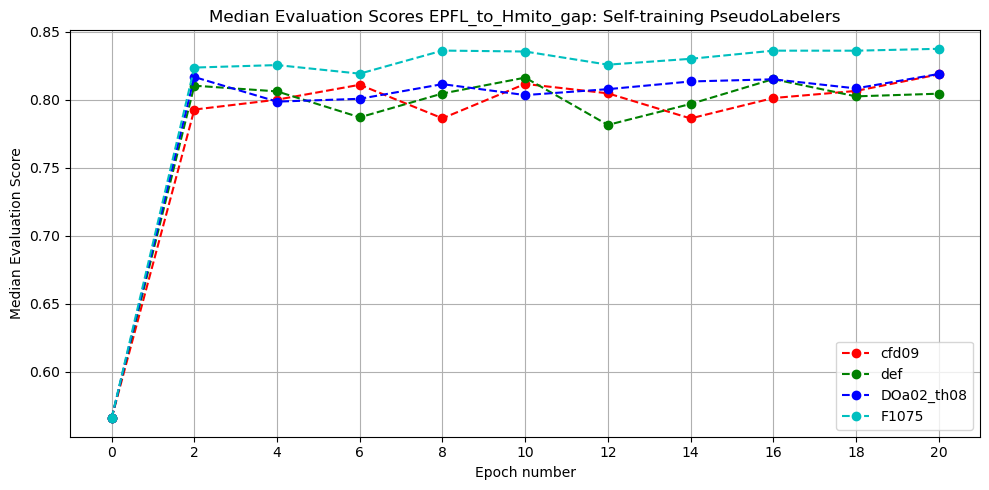

In [4]:
colours = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray']
for transfer, model_list in models.items():
    print(f"Transfer: {transfer}")
    _ = plt.figure(figsize=(10,5))
    for i, model_name in enumerate(model_list):
        if "SS" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/SemiSupervised-Finetuning/Mitochondria")
        elif "SF" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-Finetuning/Mitochondria")
        elif "ST" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-training/Mitochondria")
        else:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria")
        approach = None
        label = None
        for key in approach_mapping:
            if key in model_name:
                approach = approach_mapping[key]
                if key == "DO":
                    label = "_".join(model_name.split("_")[1:3])
                else:
                    label = model_name.split("_")[1]
                break

        assert approach is not None, f"Approach not found for model: {model_name}"
        assert label is not None, f"Label not found for model: {model_name}"

        pred_path = find_selftraining_pred_paths([model_name], approach=approach, base_path=base_path)[0]

        yaml_path = pred_path.parent.parent.parent / "self_training_config.yaml"
        base_model_name = Path(load_config_direct(yaml_path)[0]["training"]["model_cfg"]["source_checkpoint"]).parent.stem
        transfer = identify_transfer(pred_path)
        assert transfer is not None, f"Transfer section not found in path: {pred_path}"
        target = transfer.split("_")[2]
        if target == "VNC":
            result_folder = "resized"
        else:
            result_folder = "FP_3"
        paths = get_output_paths(
            transfer.split("_")[0], 
            transfer.split("_")[2], 
            {"none": []}, 
            [None], 
            base_model_name, 
            "predictions", 
            result_folder =result_folder, 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(paths) == 1, f"Expected one path for {transfer} {base_model_name}, found {len(paths)}"
        direct_pred_path = list(Path(paths[0]).glob("*.h5"))
        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")
        eval_direct_median = np.median(eval_score_direct, axis=0)

        if "_SF_" in model_name:
            epoch_ids = list(range(1, 21, 2))
            #epoch_ids = list(range(1, 5, 2))
        else:
            epoch_ids = list(range(2, 22, 2))
            #epoch_ids = list(range(1, 3, 1))


        mean_eval_scores, median_eval_scores = get_ckpt_eval_scores(pred_path, epoch_ids)
        median_eval_scores.insert(0, eval_direct_median[1])
        epochs = list(range(0, 22, 2))
        #epochs = epoch_ids.copy()
        #epochs.insert(0,0)  # Include the direct evaluation at epoch 0
        
        _ = plt.plot(epochs, median_eval_scores, marker='o', linestyle='--', color=colours[i], label=label)

    _ =plt.title(f'Median Evaluation Scores {transfer}: Self-training PseudoLabelers')
    _ =plt.xlabel('Epoch number')
    _ =plt.ylabel(f'Median Evaluation Score')
    _ = plt.xticks(epochs)
    _ = plt.legend()
    plt.grid()
    plt.tight_layout()
        #plt.savefig("mean_eval_scores_over_checkpoints.png")
    plt.show()


Transfer: HtoE


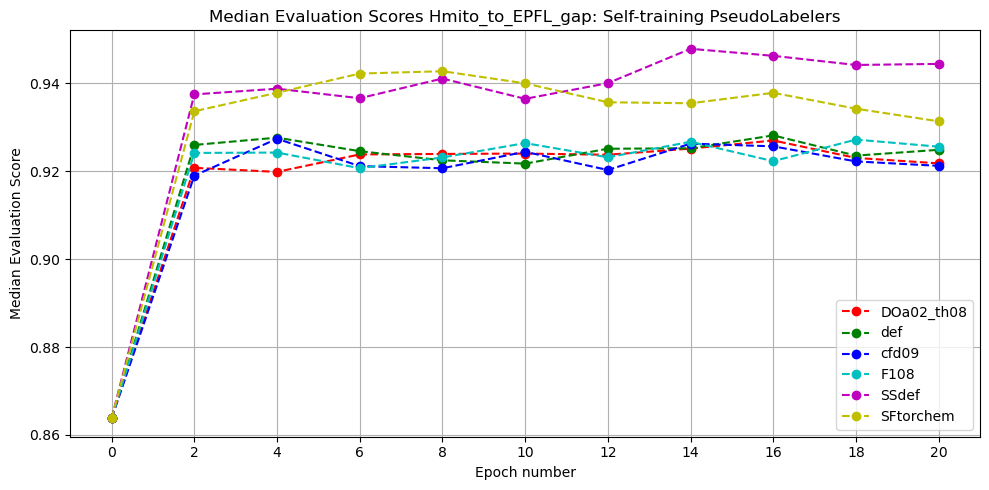

Transfer: VtoE


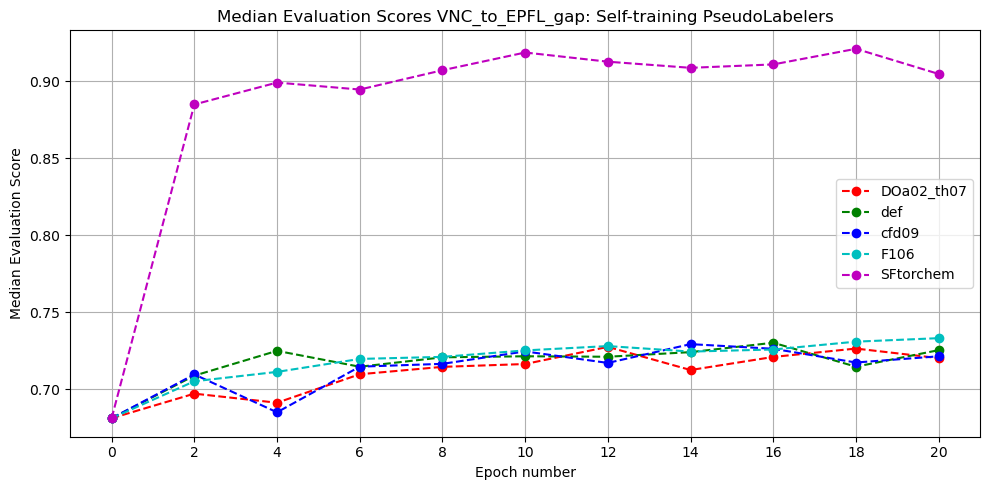

Transfer: HtoR


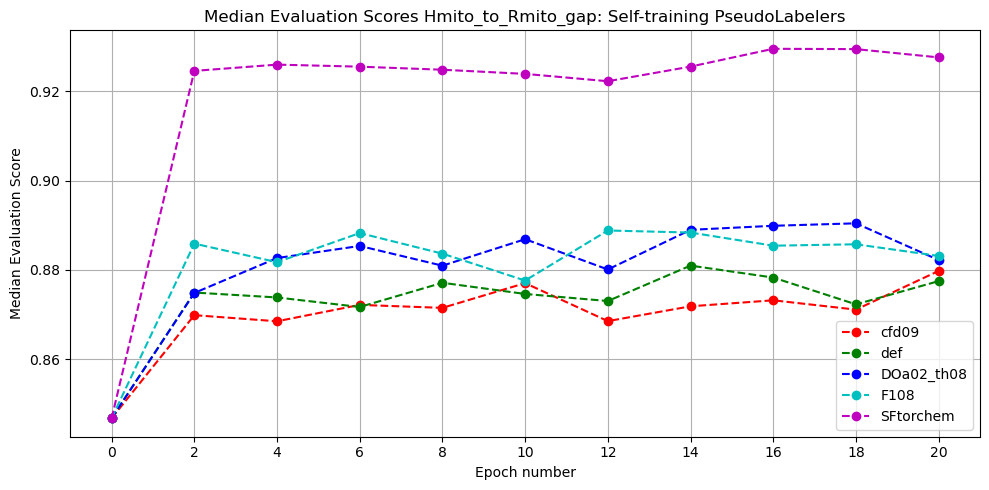

Transfer: RtoH


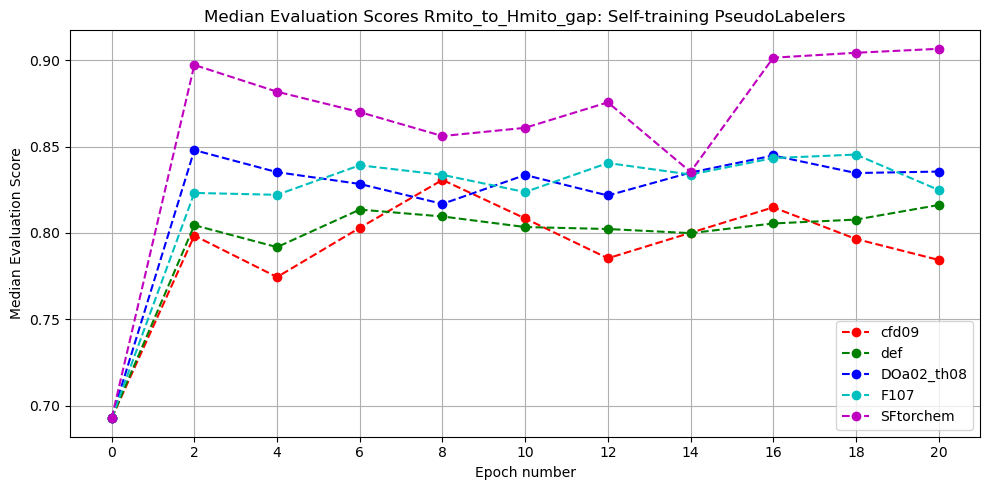

Transfer: EtoH


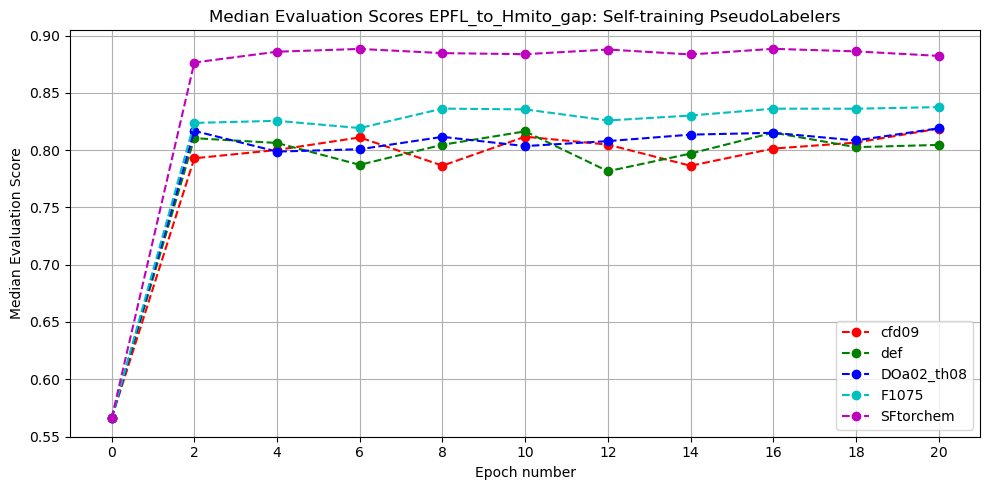

Transfer: EtoR


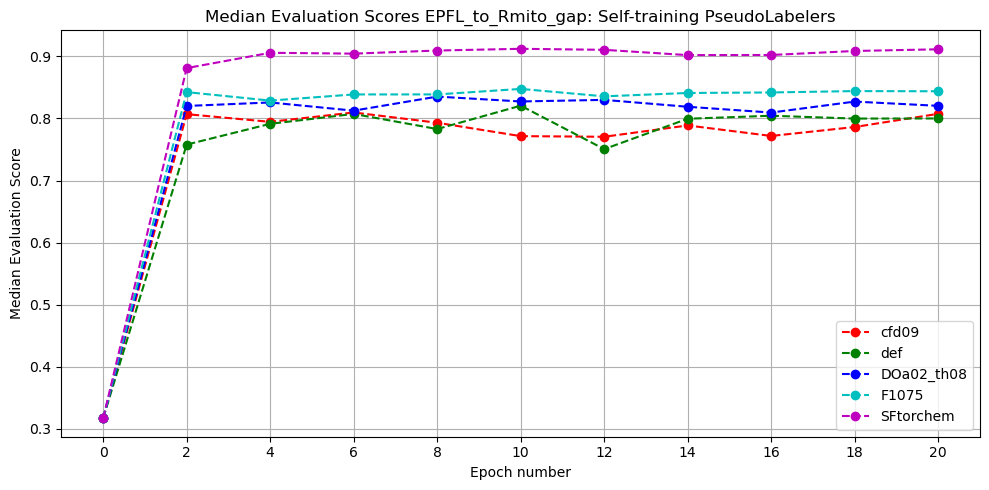

Transfer: EtoV


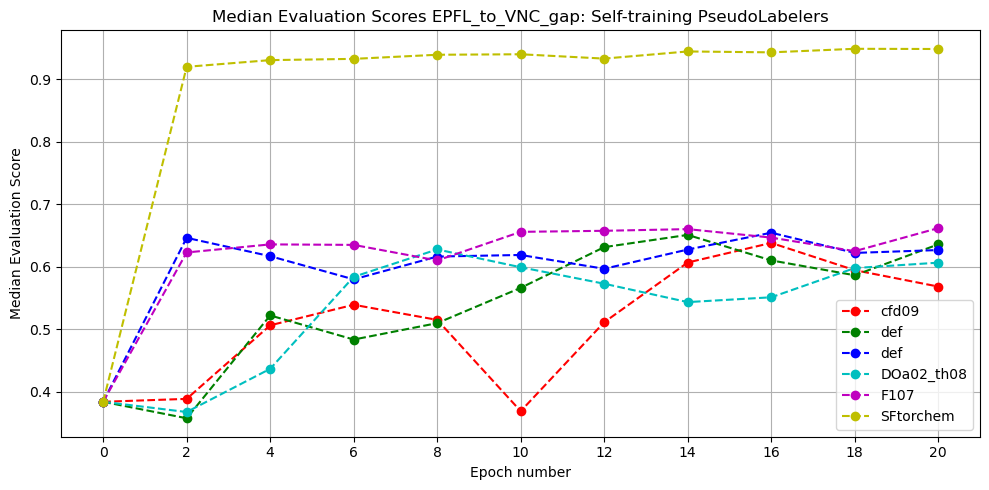

Transfer: HtoV


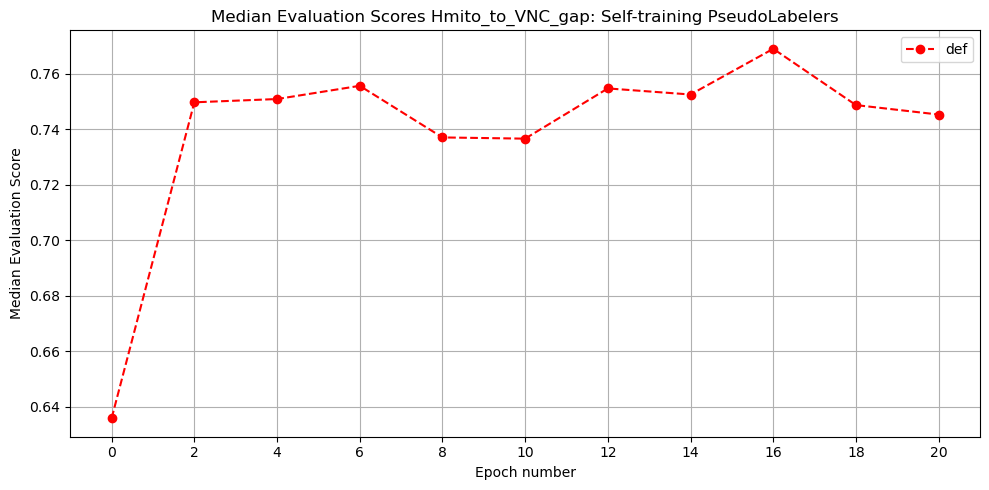

Transfer: RtoE


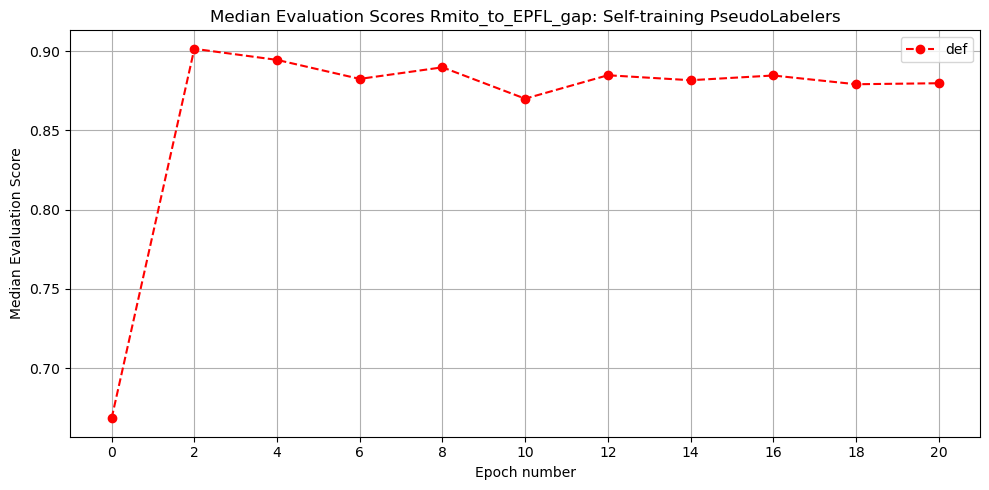

Transfer: RtoV


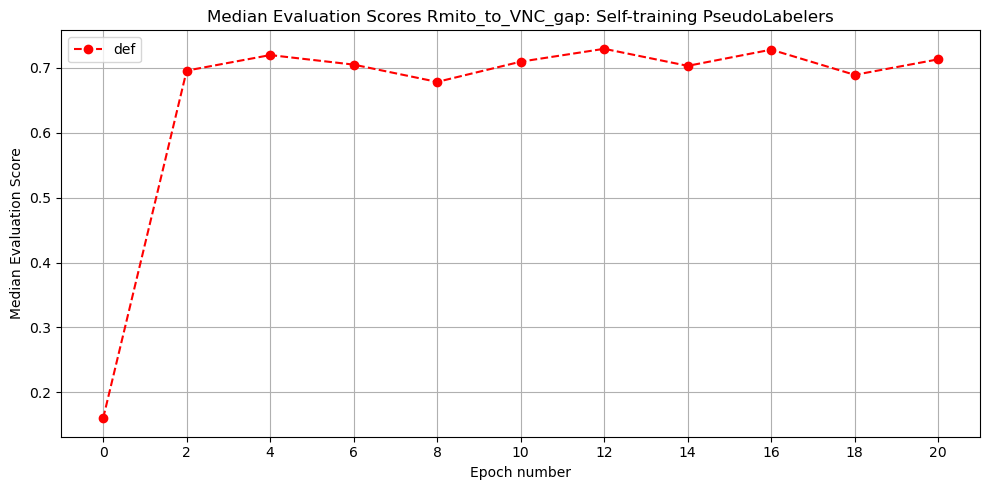

Transfer: VtoH


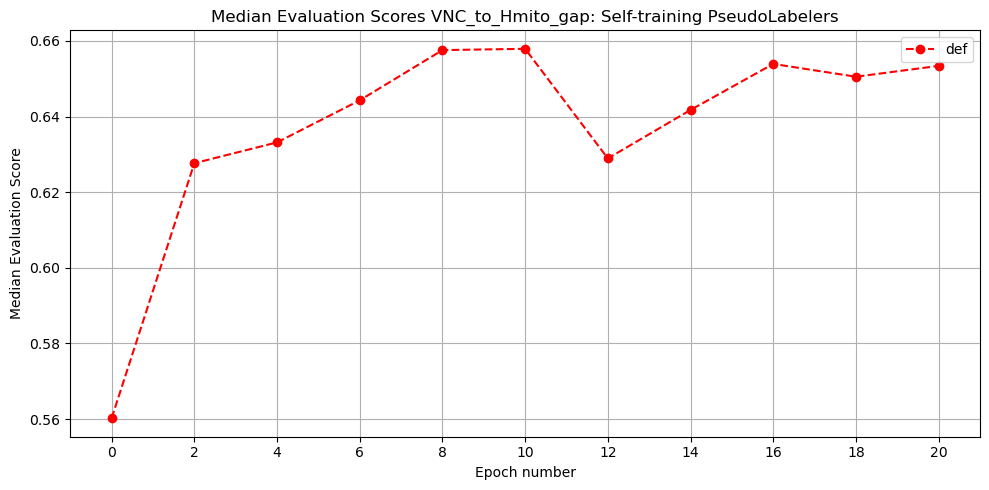

Transfer: VtoR


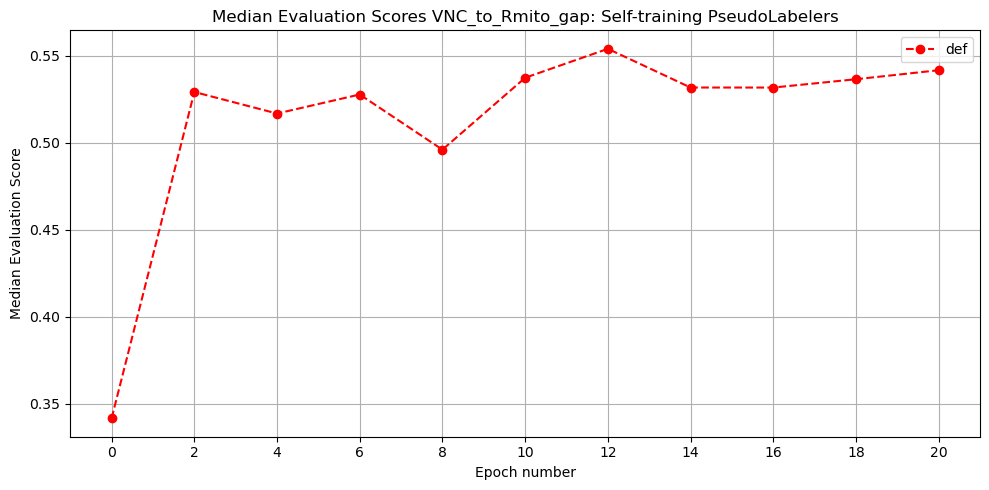

In [4]:

colours = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray']
for transfer, model_list in models.items():
    print(f"Transfer: {transfer}")
    _ = plt.figure(figsize=(10,5))
    for i, model_name in enumerate(model_list):
        if "SS" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/SemiSupervised-Finetuning/Mitochondria")
        elif "SF" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-Finetuning/Mitochondria")
        elif "ST" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-training/Mitochondria")
        else:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria")
        approach = None
        label = None
        for key in approach_mapping:
            if key in model_name:
                approach = approach_mapping[key]
                if key == "DO":
                    label = "_".join(model_name.split("_")[1:3])
                else:
                    label = model_name.split("_")[1]
                break

        assert approach is not None, f"Approach not found for model: {model_name}"
        assert label is not None, f"Label not found for model: {model_name}"

        pred_path = find_selftraining_pred_paths([model_name], approach=approach, base_path=base_path)[0]

        yaml_path = pred_path.parent.parent.parent / "self_training_config.yaml"
        base_model_name = Path(load_config_direct(yaml_path)[0]["training"]["model_cfg"]["source_checkpoint"]).parent.stem
        transfer = identify_transfer(pred_path)
        assert transfer is not None, f"Transfer section not found in path: {pred_path}"
        target = transfer.split("_")[2]
        if target == "VNC":
            result_folder = "resized"
        else:
            result_folder = "FP_3"
        paths = get_output_paths(
            transfer.split("_")[0], 
            transfer.split("_")[2], 
            {"none": []}, 
            [None], 
            base_model_name, 
            "predictions", 
            result_folder =result_folder, 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(paths) == 1, f"Expected one path for {transfer} {base_model_name}, found {len(paths)}"
        direct_pred_path = list(Path(paths[0]).glob("*.h5"))
        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")
        eval_direct_median = np.median(eval_score_direct, axis=0)

        if "_SF_" in model_name:
            epoch_ids = list(range(1, 21, 2))
            #epoch_ids = list(range(1, 5, 2))
        else:
            epoch_ids = list(range(2, 22, 2))
            #epoch_ids = list(range(1, 3, 1))


        mean_eval_scores, median_eval_scores = get_ckpt_eval_scores(pred_path, epoch_ids)
        median_eval_scores.insert(0, eval_direct_median[1])
        epochs = list(range(0, 22, 2))
        #epochs = epoch_ids.copy()
        #epochs.insert(0,0)  # Include the direct evaluation at epoch 0
        
        _ = plt.plot(epochs, median_eval_scores, marker='o', linestyle='--', color=colours[i], label=label)

    _ =plt.title(f'Median Evaluation Scores {transfer}: Self-training PseudoLabelers')
    _ =plt.xlabel('Epoch number')
    _ =plt.ylabel(f'Median Evaluation Score')
    _ = plt.xticks(epochs)
    _ = plt.legend()
    plt.grid()
    plt.tight_layout()
        #plt.savefig("mean_eval_scores_over_checkpoints.png")
    plt.show()
